<a href="https://colab.research.google.com/github/lynnkaram/ai-course-projects/blob/main/project-4-promptable-cancer-segmentation/promptable_cancer_segmentation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Promptable Cancer Segmentation Using Minimal Data 🧬

**Paper:** [Promptable cancer segmentation using minimal expert-curated data](https://arxiv.org/abs/2505.17915) by Karam et al. (2025)

*The paper was published in the 2025 Medical Imaging Understanding and Analysis Conference at the University of Leeds.*

## Introduction: the problem

### Why is cancer segmentation challenging?

Imagine you're a radiologist looking at an MRI scan of a prostate. Your job is to:
1. Find where the cancer is
2. Draw precise boundaries around it
3. Do this for hundreds of patients

This is time-consuming (it takes 7+ minutes per scan), expensive (it requires expert radiologists), and subjective (different experts often disagree on boundaries). For prostate cancer specifically, the shape of the organ is an additional challenge.

### The traditional Deep Learning approach

Standard DL methods require hundreds or thousands of fully-annotated (fully segmented) images for training. This means that every individual pixel in a medical image must be annotated/labeled 1 if it contains cancer, and 0 if it does not. Examples of standard methods are below:

```
Name of standard method + training data required
--> U-Net: 1200 fully segmented images
--> SAM (fine-tuned): 200 fully segmented images
--> Other state-of-the-art methods: 275-503 fully segmented images
```

**Problem:** With so many annotations needed, it's almost impossible to ensure high quality segmentation through consensus!

### Solution

The paper proposes a promptable segmentation method that performs better than the standard method. Promptable segmentation means the segmentation (i.e. outlining the cancerous tumor) begins after a prompt (in this case, a click). Here, it only needs:
- **8 weakly-labeled images** (just binary labels: cancer present or not in the image)
- **24 fully-segmented images** (precise boundaries/pixel-level annotations).

That's **100X less data** than the standard methods we mentioned (U-net, SAM...). With so few samples, you can easily curate them to the highest standard through expert consensus. At inference time, a user simply **clicks one point** inside the cancer region, and the algorithm automatically segments the entire lesion.

That's the general idea behind the paper, now let's see how this works in a simplified way:)

In [ ]:
# install required packages
!pip install numpy matplotlib scipy scikit-learn ipywidgets -q

# import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, Circle
from scipy import ndimage
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# set random seed for reproducibility
np.random.seed(42)

## Background: Supervised vs. Weakly-Supervised Learning

Before diving into the method, let's understand the key concepts.

### Fully-Supervised Learning

**Training input:** image crops + precise labels ("Is there cancer in this crop specifically?"). A crop is like a subsection of the image (the same as when you crop a normal image). Here the image is a MRI prostate gland scan, which we are trying to identify cancer in.

```
┌─────────────┐
│  Crop 1     │ → Label: 1 (Cancer present in this crop)
│  [10x10]    │
└─────────────┘

┌─────────────┐
│  Crop 2     │ → Label: 0 (No cancer in this crop)
│  [10x10]    │
└─────────────┘
```

- Advantage --> Very precise, it knows exactly where cancer is.
- Disadvantage --> Requires many fully-annotated images = high costs


### Weakly-Supervised Learning

**Training input:** Full images + Binary label ("Does the image contain cancer?, as in, is cancer anywhere in the image?)

```
┌─────────────┐
│ Full Image  │ → Label: 1 or 0 (Cancer somewhere in the image, or not)
│ [256x256]   │
└─────────────┘
```

- Advantage: only needs binary labels (much cheaper to obtain)
- Disadvantage: less precise about exact location


### Here's an idea: why not use both?

Here:

1. The weakly-supervised classifier is trained on 8 weakly-labelled images → this provides broad guidance
2. The fully-supervised classifier is trained on 24 fully-segmented images → this provides precise localizations
3. Combine their scores → get the best of both worlds, with a lot less data and costs compared to using only one method.

Now let's implement this step by step.

## Demo 1: Weakly-Supervised Classifier

The weakly-supervised classifier is trained on full images with binary labels:
- Input: 256x256 image
- Label: 1 (cancer present) or 0 (no cancer)

During **inference**, we can pass crops from the image and get a probability score.

To train this, we use binary cross-entropy loss function, which is a standard way to measure how far a predicted probability is from the true label. It penalizes the model more when it makes confident but wrong predictions.

$${L}_f = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(f(x_i; \theta)) + (1 - y_i) \log(1 - f(x_i; \theta))]$$

Where:
- $f(x_i; \theta)$ is the classifier, $x_i$ the input image and $\theta$ the weights
- $y_i \in \{0, 1\}$ is the binary label
- Training is done on full images
- At inference, we use crops: $f(x_i^{(w,h,d)}; \theta^*) \in [0, 1]$

*Note: you can ignore this math, it's not actually relevant for understanding the broader concepts*

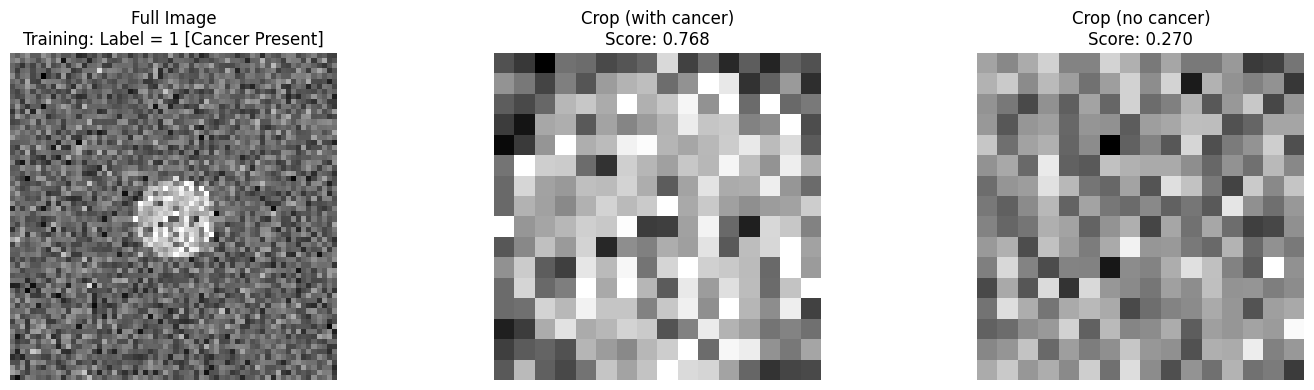

Training: Full images with binary labels (cancer yes or no)
Inference: Score individual crops
The classifier gives higher scores to crops containing cancer
Crop with cancer: 0.768
Crop without cancer: 0.270


In [ ]:
# Create synthetic data for demonstration purposes (because we don't have access to the prostate cancer MRI scans; they are in a private domain)
# Note: lesion means tumor
def create_synthetic_image_with_lesion(size=64, lesion_center=None, lesion_radius=8):
    """Create a synthetic medical image with a circular lesion"""
    image = np.random.randn(size, size) * 0.1 + 0.5  # Background

    if lesion_center is not None:
        y, x = np.ogrid[:size, :size]
        mask = (x - lesion_center[0])**2 + (y - lesion_center[1])**2 <= lesion_radius**2
        image[mask] = np.random.randn(np.sum(mask)) * 0.15 + 0.8  # Lesion (brighter)

    return np.clip(image, 0, 1)

# Simple weakly-supervised classifier (simulated)
class WeaklySupervisedClassifier:
    """Simulated weakly-supervised classifier"""

    def __init__(self):
        self.trained = True

    def predict_crop(self, crop):
        """
        Predict probability of cancer in a crop.

        In reality, this would be a CNN. The paper has a link to a github page
        where you can look more into the actual structure of that CNN. The link
        is added at the end of the tutorial for you to check it out.
        Here we simulate this by:
        - High intensity pixels → higher cancer probability
        - Low intensity pixels → lower cancer probability
        """
        mean_intensity = np.mean(crop)

        # Simulate classifier: brighter regions = higher cancer probability
        probability = 1 / (1 + np.exp(-10 * (mean_intensity - 0.6)))
        return probability

# Create a sample image with lesion
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)
classifier = WeaklySupervisedClassifier()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Full Image\nTraining: Label = 1 [Cancer Present]', fontsize=12)
axes[0].axis('off')

# Crop with cancer
crop_with_cancer = image[24:40, 24:40]
axes[1].imshow(crop_with_cancer, cmap='gray')
score_cancer = classifier.predict_crop(crop_with_cancer)
axes[1].set_title(f'Crop (with cancer)\nScore: {score_cancer:.3f}', fontsize=12)
axes[1].axis('off')

# Crop without cancer
crop_no_cancer = image[0:16, 0:16]
axes[2].imshow(crop_no_cancer, cmap='gray')
score_no_cancer = classifier.predict_crop(crop_no_cancer)
axes[2].set_title(f'Crop (no cancer)\nScore: {score_no_cancer:.3f}', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# mini summary
print("Training: Full images with binary labels (cancer yes or no)")
print("Inference: Score individual crops")
print(f"The classifier gives higher scores to crops containing cancer")
print(f"Crop with cancer: {score_cancer:.3f}")
print(f"Crop without cancer: {score_no_cancer:.3f}")

### Interactive exercise: move the crop!!

Use the sliders below to move a crop window around the image. Watch how the score changes as the crop moves over different regions. What do you notice about the output probability?

In [ ]:
# interactive crop position explorer
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)
classifier = WeaklySupervisedClassifier()
print("Try to find the cancer tumor. Move the crop to get a high score (>0.5); i.e cancer is likely to be present")
# create sliders
crop_size = 12
x_slider = widgets.IntSlider(min=0, max=64-crop_size, step=1, value=0, description='X Position:')
y_slider = widgets.IntSlider(min=0, max=64-crop_size, step=1, value=0, description='Y Position:')

output = widgets.Output()

def update_plot(x, y):
    with output:
        clear_output(wait=True)

        # Extract crop
        crop = image[y:y+crop_size, x:x+crop_size]
        score = classifier.predict_crop(crop)

        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Full image with crop rectangle
        axes[0].imshow(image, cmap='gray')
        rect = Rectangle((x, y), crop_size, crop_size, linewidth=3, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].set_title('Full Image (Red box = crop)', fontsize=12)
        axes[0].axis('off')

        # Crop with score
        axes[1].imshow(crop, cmap='gray')
        color = 'green' if score > 0.5 else 'red'
        axes[1].set_title(f'Crop Score: {score:.3f}\n({"High" if score > 0.5 else "Low"} probability)', fontsize=14, color=color)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

# Connect sliders to update function
interactive_plot = widgets.interactive(update_plot, x=x_slider, y=y_slider)
display(interactive_plot, output)

Try to find the cancer tumor. Move the crop to get a high score (>0.5); i.e cancer is likely to be present


interactive(children=(IntSlider(value=0, description='X Position:', max=52), IntSlider(value=0, description='Y…

Output()

## Demo 2: Fully-Supervised Classifier

### How it works

The fully-supervised classifier is trained on **crops** (instead of entire image) with precise labels:
- Input: Small crop (e.g., 10x10 pixels)
- Label: 1 (cancer in crop) or 0 (no cancer in crop), same as above

Here, training and inference both use crops.

### Summary so far and key differences (to clarify things)

| Aspect | Weakly-Supervised | Fully-Supervised |
|--------|-------------------|------------------|
| **Training Input** | Full images | Small crops |
| **Training Label** | Binary (image level) | Binary (crop level) |
| **Training Output** | Probability: cancer in image | Probability: cancer in crop |
| **Inference Input** | Crop from image | Crop from image |
| **Inference Output** | Probability: cancer in crop | Probability: cancer in crop |
| **Advantage** | Needs fewer annotations | More precise localization |
| **Data Required** | 8 images | 24 images (many crops per image) |

In [ ]:
# Fully-supervised classifier (simulated)
class FullySupervisedClassifier:
    """Simulated fully-supervised classifier trained on crops."""

    def __init__(self):
        self.trained = True

    def predict_crop(self, crop):
        """
        Predict probability of cancer in a crop.

        This classifier is trained on precise crop-level labels,
        so it's more sensitive to spatial patterns and edges.
        """
        mean_intensity = np.mean(crop)
        std_intensity = np.std(crop)

        # Check if this is an edge/boundary (high gradient)
        if crop.shape[0] > 1 and crop.shape[1] > 1:
            edges = np.abs(np.gradient(crop)[0]).mean() + np.abs(np.gradient(crop)[1]).mean()
            edge_score = min(edges * 5, 1.0)  # Normalize
        else:
            edge_score = 0

        # Fully-supervised: sensitive to intensity and edges (trained on precise boundaries)
        intensity_score = 1 / (1 + np.exp(-10 * (mean_intensity - 0.65)))

        # Emphasize edges more (knows boundaries well)
        probability = 0.5 * intensity_score + 0.5 * edge_score
        return probability

In [ ]:
# Demo 2: Explore the Fully-Supervised Classifier
#This classifier was trained on crops with precise labels
print("Move the crop around to see how the score changes. This is a similar idea to the previous demo.")

image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)
full_classifier = FullySupervisedClassifier()

# Create sliders
crop_size = 12
x_slider = widgets.IntSlider(min=0, max=64-crop_size, step=1, value=26, description='X Position:')
y_slider = widgets.IntSlider(min=0, max=64-crop_size, step=1, value=26, description='Y Position:')

output = widgets.Output()

def update_plot(x, y):
    with output:
        clear_output(wait=True)

        # Extract crop
        crop = image[y:y+crop_size, x:x+crop_size]
        score = full_classifier.predict_crop(crop)

        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Full image with crop rectangle
        axes[0].imshow(image, cmap='gray')
        rect = Rectangle((x, y), crop_size, crop_size, linewidth=3, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].set_title('Full Image (Red box = crop)', fontsize=12)
        axes[0].axis('off')

        # Crop with score
        axes[1].imshow(crop, cmap='gray')
        color = 'green' if score > 0.5 else 'red'
        axes[1].set_title(f'Crop\nScore: {score:.3f}', fontsize=14, color=color)
        axes[1].axis('off')

        # Score meter
        axes[2].barh(['Fully-Supervised'], [score], color=color, alpha=0.7, height=0.4)
        axes[2].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
        axes[2].set_xlim(0, 1)
        axes[2].set_xlabel('Cancer Probability', fontsize=12)
        axes[2].set_title('Classifier Output', fontsize=12)
        axes[2].legend()
        axes[2].grid(axis='x', alpha=0.3)

        # Add interpretation text
        if score > 0.5:
            interpretation = "Cancer Detected\n(Score > 0.5 threshold)"
            text_color = 'green'
        else:
            interpretation = "No Cancer\n(Score < 0.5 threshold)"
            text_color = 'red'

        axes[2].text(0.5, -0.3, interpretation, ha='center', fontsize=11, color=text_color, transform=axes[2].transAxes)
        plt.tight_layout()
        plt.show()

        # Show what the classifier is looking for
        print(f"\nWhat the classifier sees:")
        print(f"   • Position: ({x}, {y})")
        print(f"   • Mean intensity: {np.mean(crop):.3f}")
        print(f"   • Edge strength: {np.abs(np.gradient(crop)[0]).mean():.3f}")
        print(f"   • Final score: {score:.3f}")
        print(f"\nThe fully-supervised classifier looks at:")
        print(f"   1. Intensity (brightness) - cancer appears brighter")
        print(f"   2. Edges (boundaries) - trained to recognize cancer edges")

# Connect sliders to update function
interactive_plot = widgets.interactive(update_plot, x=x_slider, y=y_slider)
display(interactive_plot, output)

print("\nTry moving the crop to:")
print("   • The bright center (high score)")
print("   • The dark background (low score)")
print("   • The edges/boundaries (moderate score)")

Move the crop around to see how the score changes. This is a similar idea to the previous demo.


interactive(children=(IntSlider(value=26, description='X Position:', max=52), IntSlider(value=26, description=…

Output()


Try moving the crop to:
   • The bright center (high score)
   • The dark background (low score)
   • The edges/boundaries (moderate score)


## Demo 3: combining both classifiers (for complimentary strength)

### The joint score

From the paper (Equation 5):

$$S = \alpha \times f(x_{t}^{(w,h,d)}; \theta^*) + (1 - \alpha) \times g(x_{t}^{(w,h,d)}; \phi^*)$$

Where:
- $f$ is the weakly-supervised classifier score
- $g$ is the fully-supervised classifier score  
- $\alpha \in [0, 1]$ balances the two (hyperparameter)

Again, the math is not actually very important to contextualise things. All you need to know is that the final probability score is a combined weighted score between both classifiers. If the joint score is above a certain threshold $S_{\tau,t} = 1$, then the crop is marked as containing cancer.

$$S_{\tau,t} = \begin{cases} 1, & \text{if } S > \tau \\ 0, & \text{otherwise} \end{cases}$$

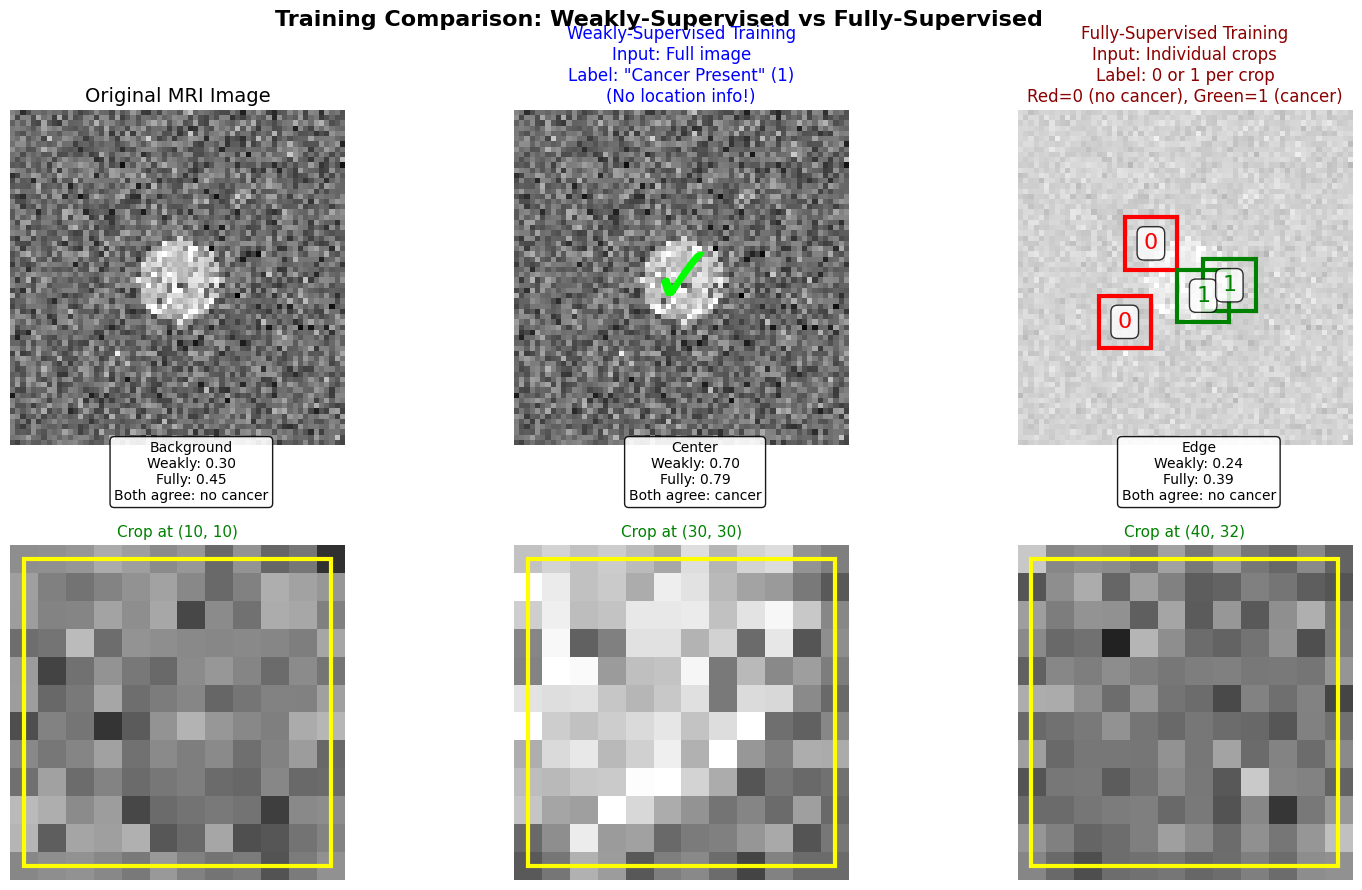

In [ ]:
# Visualization of what each classifier learns
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)

# Show the training process
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# top row = Training Data (most important)
ax_full_image = fig.add_subplot(gs[0, 0])
ax_weak_train = fig.add_subplot(gs[0, 1])
ax_full_train = fig.add_subplot(gs[0, 2])

# Full image
ax_full_image.imshow(image, cmap='gray')
ax_full_image.set_title('Original MRI Image', fontsize=14)
ax_full_image.axis('off')

# Weakly-supervised training
ax_weak_train.imshow(image, cmap='gray')
ax_weak_train.text(32, 32, '✓', fontsize=60, ha='center', va='center', color='lime')
ax_weak_train.set_title('Weakly-Supervised Training\nInput: Full image\nLabel: "Cancer Present" (1)\n(No location info!)',fontsize=12, color='blue')
ax_weak_train.axis('off')

# fully-supervised training: show multiple crops with labels
ax_full_train.imshow(image, cmap='gray', alpha=0.3)

# draw several training crops
crop_examples = [
    (20, 20, 0, 'red'),      # No cancer crop
    (30, 30, 1, 'green'),    # Cancer crop
    (15, 35, 0, 'red'),      # no cancer crop
    (35, 28, 1, 'green'),    # cancer crop
]

for x, y, label, color in crop_examples:
    rect = plt.Rectangle((x, y), 10, 10, linewidth=3, edgecolor=color, facecolor='none')
    ax_full_train.add_patch(rect)
    ax_full_train.text(x+5, y+5, str(label), fontsize=16, ha='center', va='center', color=color, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax_full_train.set_title('Fully-Supervised Training\nInput: Individual crops\nLabel: 0 or 1 per crop\nRed=0 (no cancer), Green=1 (cancer)', fontsize=12, color='darkred')
ax_full_train.axis('off')

# bottom row = example predictions
ax_crop1 = fig.add_subplot(gs[1, 0])
ax_crop2 = fig.add_subplot(gs[1, 1])
ax_crop3 = fig.add_subplot(gs[1, 2])

# Test 3 specific crops
test_crops = [
    (10, 10, "Background"),
    (30, 30, "Center"),
    (40, 32, "Edge")
]

for idx, (ax, (x, y, label)) in enumerate(zip([ax_crop1, ax_crop2, ax_crop3], test_crops)):
    crop = image[y:y+12, x:x+12]

    # Get scores
    weak_score = WeaklySupervisedClassifier().predict_crop(crop)
    full_score = FullySupervisedClassifier().predict_crop(crop)

    # Show crop
    ax.imshow(crop, cmap='gray', vmin=0, vmax=1)
    rect = plt.Rectangle((0, 0), 11, 11, linewidth=3, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect)

    # Color code the title based on detection
    both_detect = weak_score > 0.5 and full_score > 0.5
    neither_detect = weak_score < 0.5 and full_score < 0.5

    if both_detect:
        title_color = 'green'
        agreement = "Both agree: cancer"
    elif neither_detect:
        title_color = 'green'
        agreement = "Both agree: no cancer"
    else:
        title_color = 'orange'
        agreement = "Disagreement :("

    # Add scores as text
    ax.text(6, -2, f'{label}\nWeakly: {weak_score:.2f}\nFully: {full_score:.2f}\n{agreement}',
           ha='center', va='bottom', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    ax.set_title(f'Crop at ({x}, {y})', fontsize=11, color=title_color)
    ax.axis('off')

plt.suptitle('Training Comparison: Weakly-Supervised vs Fully-Supervised',
            fontsize=16, fontweight='bold', y=0.98)

plt.show()

Key takeaways:
1. Training data (top row) main difference:
- Weakly-supervised: Gets **full** image + binary label (cancer yes or no)
- Fully-supervised: Gets **individual crops** + label per crop (0 or 1)
2. At inference (bottom row):
- Both classifiers score crops the same way
- But they've learned from different training data!
3. When they agree:
- Background crop: Both say no cancer → High confidence
- Center crop: Both say cancer → High confidence
5. The benefit:
- Only 32 total images needed (8 + 24) compared to U-Net, which needs 1,200 images!
- With so few images, you can ensure high quality

## Demo 4: The Spiral Search Algorithm

### The problem

We could score **every possible crop** in the image (sliding window), but this is **slow** (too many crops to evaluate) and **computationally expensive**.

### The solution: spiral search

Starting from a **user's point prompt**, search outward in a spiral pattern. The algorithm can be modeled using Equations 7 and 8 such that:

Spiral movement:
$$\delta_w = r \times \cos(\beta)$$
$$\delta_h = r \times \sin(\beta)$$
$$\delta_d = 0$$

Where:
- $r = t/s$ (radius grows with time)
- $\beta = 2\pi \times (t/\mu)$ (angle)
- $s$ = scale parameter
- $\mu$ = steps per full circle

New position:
$$(w_{t+1}, h_{t+1}, d_{t+1}) = (w_t + \delta_w, h_t + \delta_h, d_t + \delta_d)$$

### And why a spiral specifically?

From the paper:
> "The spiral strategy is more computationally efficient compared to a full sliding window approach due to a lower number of crops processed and roughly follows the spherical shape of the prostate gland."


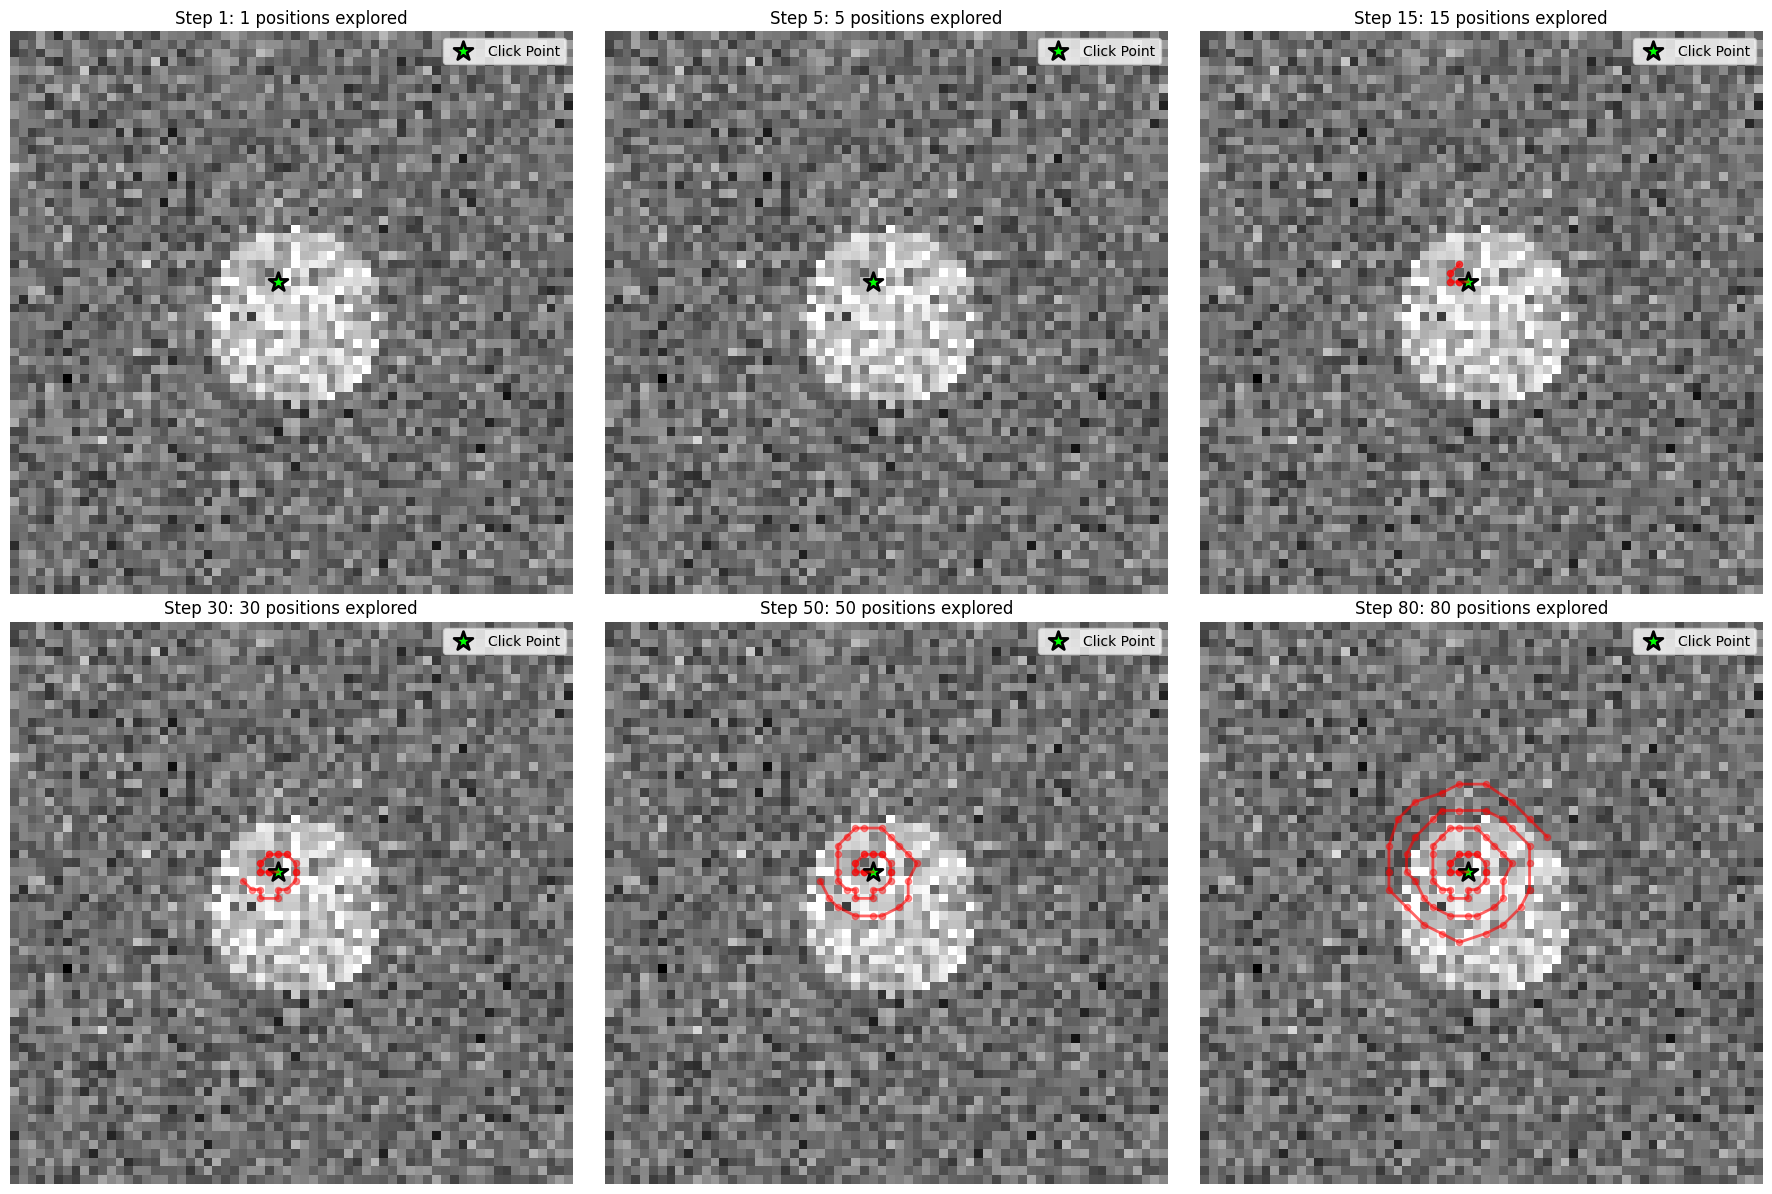

In [ ]:
# Spiral search visualization
def generate_spiral_path(center, max_steps=100, scale=10, steps_per_circle=20):
    """Generate spiral search path based on paper equations."""
    path = [center]

    for t in range(1, max_steps):
        # Calculate radius and angle (Equation 7)
        r = t / scale
        beta = 2 * np.pi * (t / steps_per_circle)

        # Calculate deltas (Equation 7)
        delta_w = r * np.cos(beta)
        delta_h = r * np.sin(beta)

        # New position (Equation 8)
        new_x = int(center[0] + delta_w)
        new_y = int(center[1] + delta_h)

        # Keep within bounds
        new_x = np.clip(new_x, 0, 63)
        new_y = np.clip(new_y, 0, 63)

        path.append((new_x, new_y))

    return path
# Create image
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=10)

# User clicks at this point
click_point = (30, 28)

# Generate spiral path
spiral_path = generate_spiral_path(click_point, max_steps=80, scale=8, steps_per_circle=20)

# Visualize progression
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

step_snapshots = [1, 5, 15, 30, 50, 80]

for idx, n_steps in enumerate(step_snapshots):
    axes[idx].imshow(image, cmap='gray')

    # Draw spiral path up to n_steps
    path_subset = spiral_path[:n_steps]
    xs = [p[0] for p in path_subset]
    ys = [p[1] for p in path_subset]

    # Plot path
    axes[idx].plot(xs, ys, 'r-', linewidth=2, alpha=0.6)
    axes[idx].scatter(xs, ys, c='red', s=20, alpha=0.4)

    # Mark start point
    axes[idx].scatter(click_point[0], click_point[1], c='lime', s=200,marker='*', edgecolors='black', linewidths=2, label='Click Point')
    axes[idx].set_title(f'Step {n_steps}: {len(path_subset)} positions explored', fontsize=12)
    axes[idx].legend(loc='upper right')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Notice how the spiral:
- Starts at the user's click point (green star)
- Searches nearby regions first
- Gradually expands outward in a spiral pattern
- Covers the lesion efficiently without checking every pixel

## Demo 5: Play around with the spiral parameters

From Table 4 in the paper, optimal hyperparameters were:
- **T** (total steps) = 80
- **μ** (steps per circle) = 200-600
- **s** (scale) varied

Play around with the values and see how the shape of the spiral changes, try to understand why these values were decided in the paper.

In [ ]:
# Interactive spiral parameter explorer
scale_slider = widgets.IntSlider(min=5, max=15, step=1, value=10, description='Scale (s):')
steps_circle_slider = widgets.IntSlider(min=10, max=30, step=5, value=20, description='Steps/circle (μ):', style={'description_width': 'initial'})
max_steps_slider = widgets.IntSlider(min=20, max=120, step=10, value=80,description='Max steps (T):', style={'description_width': 'initial'})

output = widgets.Output()
def update_spiral(scale, steps_per_circle, max_steps):
    with output:
        clear_output(wait=True)
        image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=10)
        click_point = (32, 32)
        spiral_path = generate_spiral_path(click_point, max_steps=max_steps, scale=scale, steps_per_circle=steps_per_circle)
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        ax.imshow(image, cmap='gray')

        xs = [p[0] for p in spiral_path]
        ys = [p[1] for p in spiral_path]

        # Color gradient along path
        colors = plt.cm.plasma(np.linspace(0, 1, len(spiral_path)))
        for i in range(len(spiral_path)-1):
            ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]], c=colors[i], linewidth=2, alpha=0.6)

        ax.scatter(click_point[0], click_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidths=3, label='Start', zorder=5)
        ax.set_title(f'Spiral Search Pattern\n(scale={scale}, μ={steps_per_circle}, T={max_steps})', fontsize=14)
        ax.legend(loc='upper right', fontsize=12)
        ax.axis('off')

        plt.tight_layout()
        plt.show()


interactive_plot = widgets.interactive(update_spiral, scale=scale_slider,steps_per_circle=steps_circle_slider, max_steps=max_steps_slider)
display(interactive_plot, output)

interactive(children=(IntSlider(value=10, description='Scale (s):', max=15, min=5), IntSlider(value=20, descri…

Output()

Some notes:
- Lower scale (s) --> tighter spiral
- Higher scale (s) --> wider spiral
- Lower μ --> faster rotation
- Higher μ --> slower rotation

## Demo 6: Understanding the Threshold (τ)

Building onto what was discussed in Demo 3, after combining both classifiers, we get a combined score `S` for each crop. But how do we decide if that score means "cancer detected" or "no cancer"? That's where the threshold (τ) comes in!

From the paper (Equation 6):

$$S_{\tau,t} = \begin{cases} 1, & \text{if } S > \tau \\ 0, & \text{otherwise} \end{cases}$$

Where:
- If score > threshold --> Cancer detected
- If score ≤ threshold --> No cancer

### Why does threshold matter?

The threshold controls the **sensitivity vs specificity tradeoff**:

| Threshold | Effect | Use Case |
|-----------|--------|----------|
| Low (e.g., 0.05) | More detections (high sensitivity) | Medical screening - don't miss any cancer! |
| Medium (e.g., 0.5) | Balanced | General use |
| High (e.g., 0.8) | Fewer detections (high specificity) | Reduce false positives |

In the paper (Table 4), the optimal threshold was found to be τ = 0.05 (which is very low, I know). There is no particular reason why this threshold was so low, other than it just worked best when the code was being tested. It was simply the optimal value given the prostate cancer dataset.

However, the low threshold does makes sense for cancer detection - it's better to catch all potential cases (even with some false positives) than to miss actual cancer.

So now for this demo, let's explore how changing the threshold affects detection.

In [ ]:
# Demo: explore how the threshold (τ) affects detection
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)
weak_classifier = WeaklySupervisedClassifier()
full_classifier = FullySupervisedClassifier()
threshold_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description='Threshold (τ):', style={'description_width': 'initial'})
output = widgets.Output()

def update_threshold(tau):
    with output:
        clear_output(wait=True)

        # Test on multiple crops
        test_positions = [(10, 10), (25, 25), (32, 32), (40, 40)]

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        for idx, (x, y) in enumerate(test_positions):
            crop = image[y:y+12, x:x+12]

            # Get combined score
            weak_score = weak_classifier.predict_crop(crop)
            full_score = full_classifier.predict_crop(crop)
            combined = 0.5 * weak_score + 0.5 * full_score

            # Apply threshold
            detected = combined > tau

            # Show crop
            axes[idx].imshow(crop, cmap='gray')
            color = 'green' if detected else 'red'
            axes[idx].set_title(f'Score: {combined:.2f}\n{"Detected" if detected else "Not Detected"}',
                              fontsize=10, color=color)
            axes[idx].axis('off')

            # Add rectangle
            rect = plt.Rectangle((0, 0), 11, 11, linewidth=3,
                                edgecolor=color, facecolor='none')
            axes[idx].add_patch(rect)

        plt.suptitle(f'Threshold τ = {tau:.2f}', fontsize=14)
        plt.tight_layout()
        plt.show()

        print(f"\nWith threshold τ = {tau:.2f}:")
        print(f"   • Lower threshold --> More detections (more sensitive)")
        print(f"   • Higher threshold --> Fewer detections (more conservative)")

interactive_plot = widgets.interactive(update_threshold, tau=threshold_slider)
display(interactive_plot, output)

interactive(children=(FloatSlider(value=0.5, description='Threshold (τ):', max=1.0, step=0.05, style=SliderSty…

Output()

## Demo 7: Understanding Crop Size

Throughout this tutorial, we've been using crops to classify cancer. But how big should these crops be?

#### First, what is a crop?

A crop is a small window (e.g., 10x10 pixels) that we extract from the full image and pass to our classifiers. Think of it like looking at the image through a magnifying glass.

#### Why does the size of the crop matter?

The size of the crop affects what the classifier "sees".

| Crop Size | Advantages | Disadvantages |
|-----------|------------|---------------|
| Small (6x6) | Precise localization, fast computation | May miss context, might not capture full lesion |
| Medium (10x10) | Good balance | Optimal (according to paper) |
| Large (20x20) | More context, sees bigger picture | May include healthy tissue, less precise |

### From the Paper (Figure 3)

In the paper, we tested different crop sizes and found:
- Optimal crop size: 10x10x6 (width x height x depth/nb of slices)
- Too small --> Misses important context
- Too large --> Includes irrelevant background noise

In [ ]:
# Demo: How crop size affects classification
image = create_synthetic_image_with_lesion(size=64, lesion_center=(32, 32), lesion_radius=8)
weak_classifier = WeaklySupervisedClassifier()
crop_size_slider = widgets.IntSlider(min=6, max=20, step=2, value=12, description='Crop Size:', style={'description_width': 'initial'})
output = widgets.Output()

def update_crop_size(crop_size):
    with output:
        clear_output(wait=True)

        # Fixed position (center of lesion)
        x, y = 26, 26

        # Extract crop
        crop = image[y:y+crop_size, x:x+crop_size]
        score = weak_classifier.predict_crop(crop)

        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Full image with crop
        axes[0].imshow(image, cmap='gray')
        rect = Rectangle((x, y), crop_size, crop_size, linewidth=3,  edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].set_title('Full Image', fontsize=12)
        axes[0].axis('off')

        # Crop
        axes[1].imshow(crop, cmap='gray')
        axes[1].set_title(f'Crop Size: {crop_size}×{crop_size}\nScore: {score:.3f}', fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"Crop Size: {crop_size}×{crop_size}")
        print(f"Score: {score:.3f}")
interactive_plot = widgets.interactive(update_crop_size, crop_size=crop_size_slider)
display(interactive_plot, output)

interactive(children=(IntSlider(value=12, description='Crop Size:', max=20, min=6, step=2, style=SliderStyle(d…

Output()

## Full pipeline algorithm with point prompts (i.e. bringing it all together)

Now let's see the complete algorithm. Here are the steps:

1. **User clicks** a point inside the lesion
2. **Spiral search** starts from that point
3. At each position:
   - Extract crop
   - Score with **both classifiers**
   - Combine scores: $S = \alpha \cdot f(\text{crop}) + (1-\alpha) \cdot g(\text{crop})$
   - If $S > \tau$, mark as cancer
4. **Combine all positive crops** to get the final segmentation.

## Paper's results and discussion

### Performance Comparison

From Table 1 in the paper:

| Method | Training Data | Dice Score | Promptable? |
|--------|--------------|------------|-------------|
| **This Paper** | **8 weak + 24 full** | **0.3085** | **Yes** |
| SAM | 200 full | 0.2361 | Yes |
| MedSAM | 200 full | 0.2673 | Yes |
| U-Net | 1200 full | 0.3275 | No |
| Yi et al. | 275 full | 0.3392 | No |
| Yan et al. | 503 full | 0.3300 | No |

### Key findings

1. **Data Efficiency**: The paper uses **100X less fully-annotated data** than U-Net
   - U-Net: 1200 images vs this paper: 24 images (+ 8 weak labels)

2. **Competitive Performance**: Achieves comparable Dice score (meaning overlap between the actual tumor and what was segmented as a tumor) to State-of-the-arts methods

3. **Superior to other Promptable Methods**:
   - Significantly better than SAM
   - Significantly better than MedSAM

4. **Fast Inference**: 4.2 seconds vs 439.6 seconds for human expert!


## Conclusion

### What we learned

This paper presents a novel approach for **promptable cancer segmentation** that:

1. **Uses Minimal Data**
   - Only 8 weakly-labeled + 24 fully-segmented images
   - 100X less than traditional methods
   - Enables high-quality consensus annotations

2. **Combines Two Classifiers**
   - Weakly-supervised: Broad guidance from binary labels
   - Fully-supervised: Precise localization from segmentations
   - Together: Best of both worlds!

3. **Uses Efficient Search**
   - Spiral pattern from user's click
   - Faster than sliding window
   - Follows anatomy (spherical prostate)

4. **Achieves Strong Results**
   - Dice score: 0.3085 (comparable to SOTA)
   - Significantly better than SAM/MedSAM
   - 4.2s vs 439.6s for human expert

#### Connection to class concepts:

1. **Neural Networks**: Both classifiers use 3D CNNs
   - Convolutional layers extract features
   - Binary classification output
*These are in the Github repo (link below)*

2. **Supervised Learning**: Traditional approach
   - Requires precise labels
   - More accurate but expensive

3. **Weakly-Supervised Learning**: Modern innovation
   - Uses cheaper binary labels
   - Learns to localize from image-level labels

4. **Ensemble Methods**: Combining models
   - Multiple classifiers = better results
   - Weighted average balances strengths

5. **Search Algorithms**: Spiral search
   - Efficient exploration strategy
   - Domain knowledge (spherical anatomy)

### Why this matters:

**Clinical Impact:** Faster diagnoses (4.2s vs 7+ minutes), more consistent (no inter-observer variability), accessible (needs minimal expert time)

**Research Impact:** Data-efficient learning paradigm, applicable beyond prostate cancer, enables high-quality small datasets

**Methodological Innovation:** bridges weak and full supervision, interactive AI (promptable) and efficient inference strategy

Future directions include:
1. Applying this to other organs/cancers
2. Explore other search strategies
3. Optimize for different data availability scenarios
4. Investigate balancing over/under-prediction

Overall, this enables practical deployment in clinical settings where expert time is limited!

Look at the CNNs and the code in more detail, the code is available at: `github.com/lynnkaram/promptable-cancer-segmentation`


